## EdU analysis

This notebook performs a staging of cells labeled by IF using EdU and Hoechst signal, as done by Peter Whitney

In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9 
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define the repo directory where the data are located
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

# List the experiments to read data for
experiment_list = ["10012025_hCEC_gH2AX-EdU", "10062025_hCEC_gH2AX-EdU"]

In [3]:
# Read in the cell_metrics data frame 

# Initialize a list to hold the cell_metrics data
cell_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    metrics_path = os.path.join(repo_directory, "results", experiment, "cell_metrics_postBS.csv")
    
    try:
        # Read the CSV files
        metrics_df = pd.read_csv(metrics_path)
        
        # Append the DataFrame to the list
        cell_metrics_list.append(metrics_df)
        
    except Exception as e:
        logging.error(f"Error reading {metrics_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
cell_metrics = pd.concat(cell_metrics_list, ignore_index=True)

# Rename ROI_index to ROI
cell_metrics.rename(columns = {"ROI_index": "ROI"}, inplace = True)

# Turn channel from 0-indexed to 1-indexed
cell_metrics['channel'] = cell_metrics['channel'] + 1

In [4]:
# Print the top of the data frame for inspection
print(cell_metrics.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name  ROI  channel   area  \
0  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...    3        1  20293   
1  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...    3        2  20293   
2  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...    3        3  20293   
3  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...    3        4  20293   
4  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...    5        1   7712   

           avg  median         std  maxima  minima           plasmid  \
0  2006.732420  1996.0  477.832764  3662.0   808.0  pLenti_sgRNA18-4   
1   187.268910   181.0   86.999459  3422.0    77.0  pLenti_sgRNA18-4   
2  1708.065786  1562.0  779.049821  7871.0   443.0  pLenti_sgR

In [5]:
# Calculate the sum intensity for each nucleus, as Peter's pipeline uses that, not the mean
cell_metrics['sum_int'] = cell_metrics['area'] * cell_metrics['avg']

In [6]:
# Pivot the combined data frame to wide format, separating each channel into one variable, 
# to plot Hoechst vs EdU sum intensity as scatterplot

# Extract a subset of columns into a new data frame
wide_df = cell_metrics[['experiment', 'image_index', 'base_name', 'plasmid', 
                        'genotype', 'cell_line', 'timepoint',
                        'ROI', 'channel', 'sum_int']]

group_indices = ['experiment', 'image_index', 'base_name', 'plasmid', 
                 'genotype', 'cell_line', 'timepoint', 'ROI']

# Pivot wide_df to get separate columns for each channel's sum_int
wide_df = wide_df.pivot(
    index = group_indices,  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'sum_int'  # Values to fill with
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_df.columns = [f"{col}_sum_int" if isinstance(col, int) else col for col in wide_df.columns]
wide_df.rename(columns = {
    '1_sum_int': 'ch1_sum_int',
    '2_sum_int': 'ch2_sum_int', 
    '3_sum_int': 'ch3_sum_int', 
    '4_sum_int': 'ch4_sum_int'
}, inplace = True)

In [7]:
print(wide_df.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name           plasmid  \
0  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
1  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
2  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
3  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
4  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   

          genotype   cell_line timepoint  ROI  ch1_sum_int  ch2_sum_int  \
0  dCas9:mStayGold  hCEC (D29)        t2    3   40722621.0    3800248.0   
1  dCas9:mStayGold  hCEC (D29)        t2    5   22000254.0    3362243.0   
2  dCas9:mStayGold  hCEC (D29)        t2    6   28706829.0    1853845.0

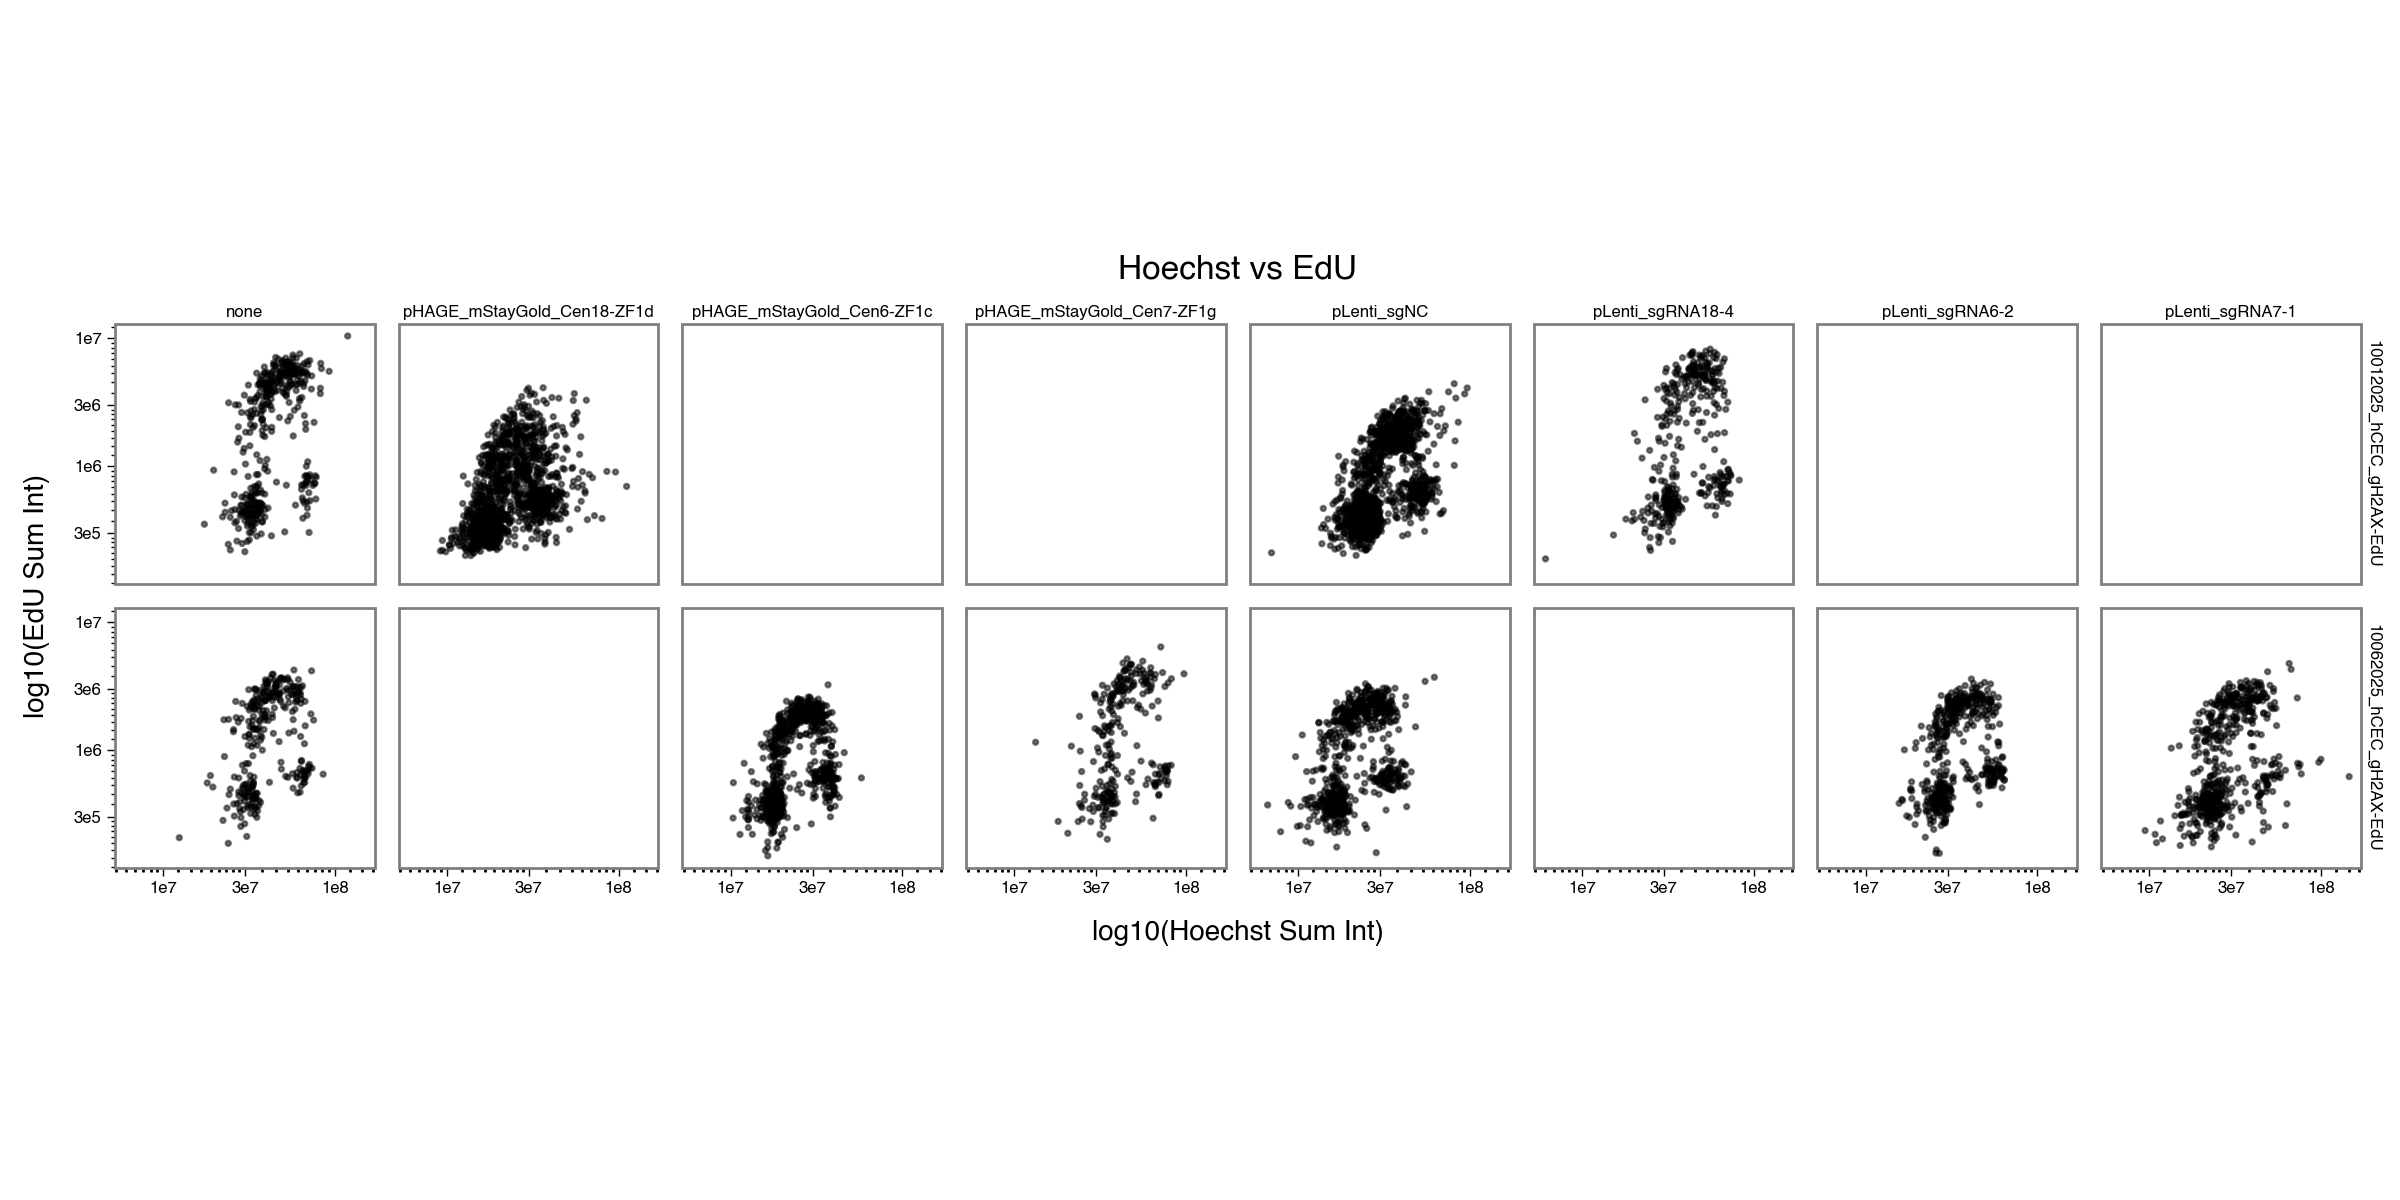

In [8]:
# Make a scatter plot of Hoechst sum intensity vs EdU sum intensity (both as log)
# for each of the experimental groups ("plasmid")

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_sum_int', 
                               y = 'ch4_sum_int')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.scale_x_log10() +
    p9.scale_y_log10() +
    p9.labs(
        title = 'Hoechst vs EdU',
        x = 'log10(Hoechst Sum Int)',
        y = 'log10(EdU Sum Int)'
    ) + 
    p9.facet_grid('experiment ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill = 'white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

The scatterplots show generally the distribution that we would expect for these data, but they would benefit from some re-scaling of the values, so let's do that before binning for cell cycle phases

In [9]:
# Load functions to re-scale Hoechst and EdU values 
# for easier comparison between experimental groups
# These are stored in cc_rescale.py 

from cc_rescale import rescale_hoechst, rescale_edu

In [10]:
# Run the Hoechst re-scaling function above using the "biological" method, instead of Z-scoring:
# Adjust grouping variables (group_cols) as needed, if other than "experiment" and "plasmid"

wide_df["ch1_scaled"], scale_params = rescale_hoechst(
    wide_df,
    hoechst_col = "ch1_sum_int",
    group_cols = ("experiment", "plasmid"),
    method = "biological",
    return_params = True
)

In [11]:
# Run the EdU re-scaling function above using the "biological" method, instead of Z-scoring:
# Adjust grouping variables (group_cols) as needed, if other than "experiment" and "plasmid"

wide_df["ch4_scaled"], edu_params = rescale_edu(
    wide_df,
    edu_col = "ch4_sum_int",
    group_cols = ("experiment", "plasmid"),
    method = "biological",
    return_params = True, 
    clip_01 = False
)

In [12]:
# Inspect if necessary
print(wide_df.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name           plasmid  \
0  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
1  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
2  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
3  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
4  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   

          genotype   cell_line timepoint  ROI  ch1_sum_int  ch2_sum_int  \
0  dCas9:mStayGold  hCEC (D29)        t2    3   40722621.0    3800248.0   
1  dCas9:mStayGold  hCEC (D29)        t2    5   22000254.0    3362243.0   
2  dCas9:mStayGold  hCEC (D29)        t2    6   28706829.0    1853845.0

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 121 rows containing missing values.


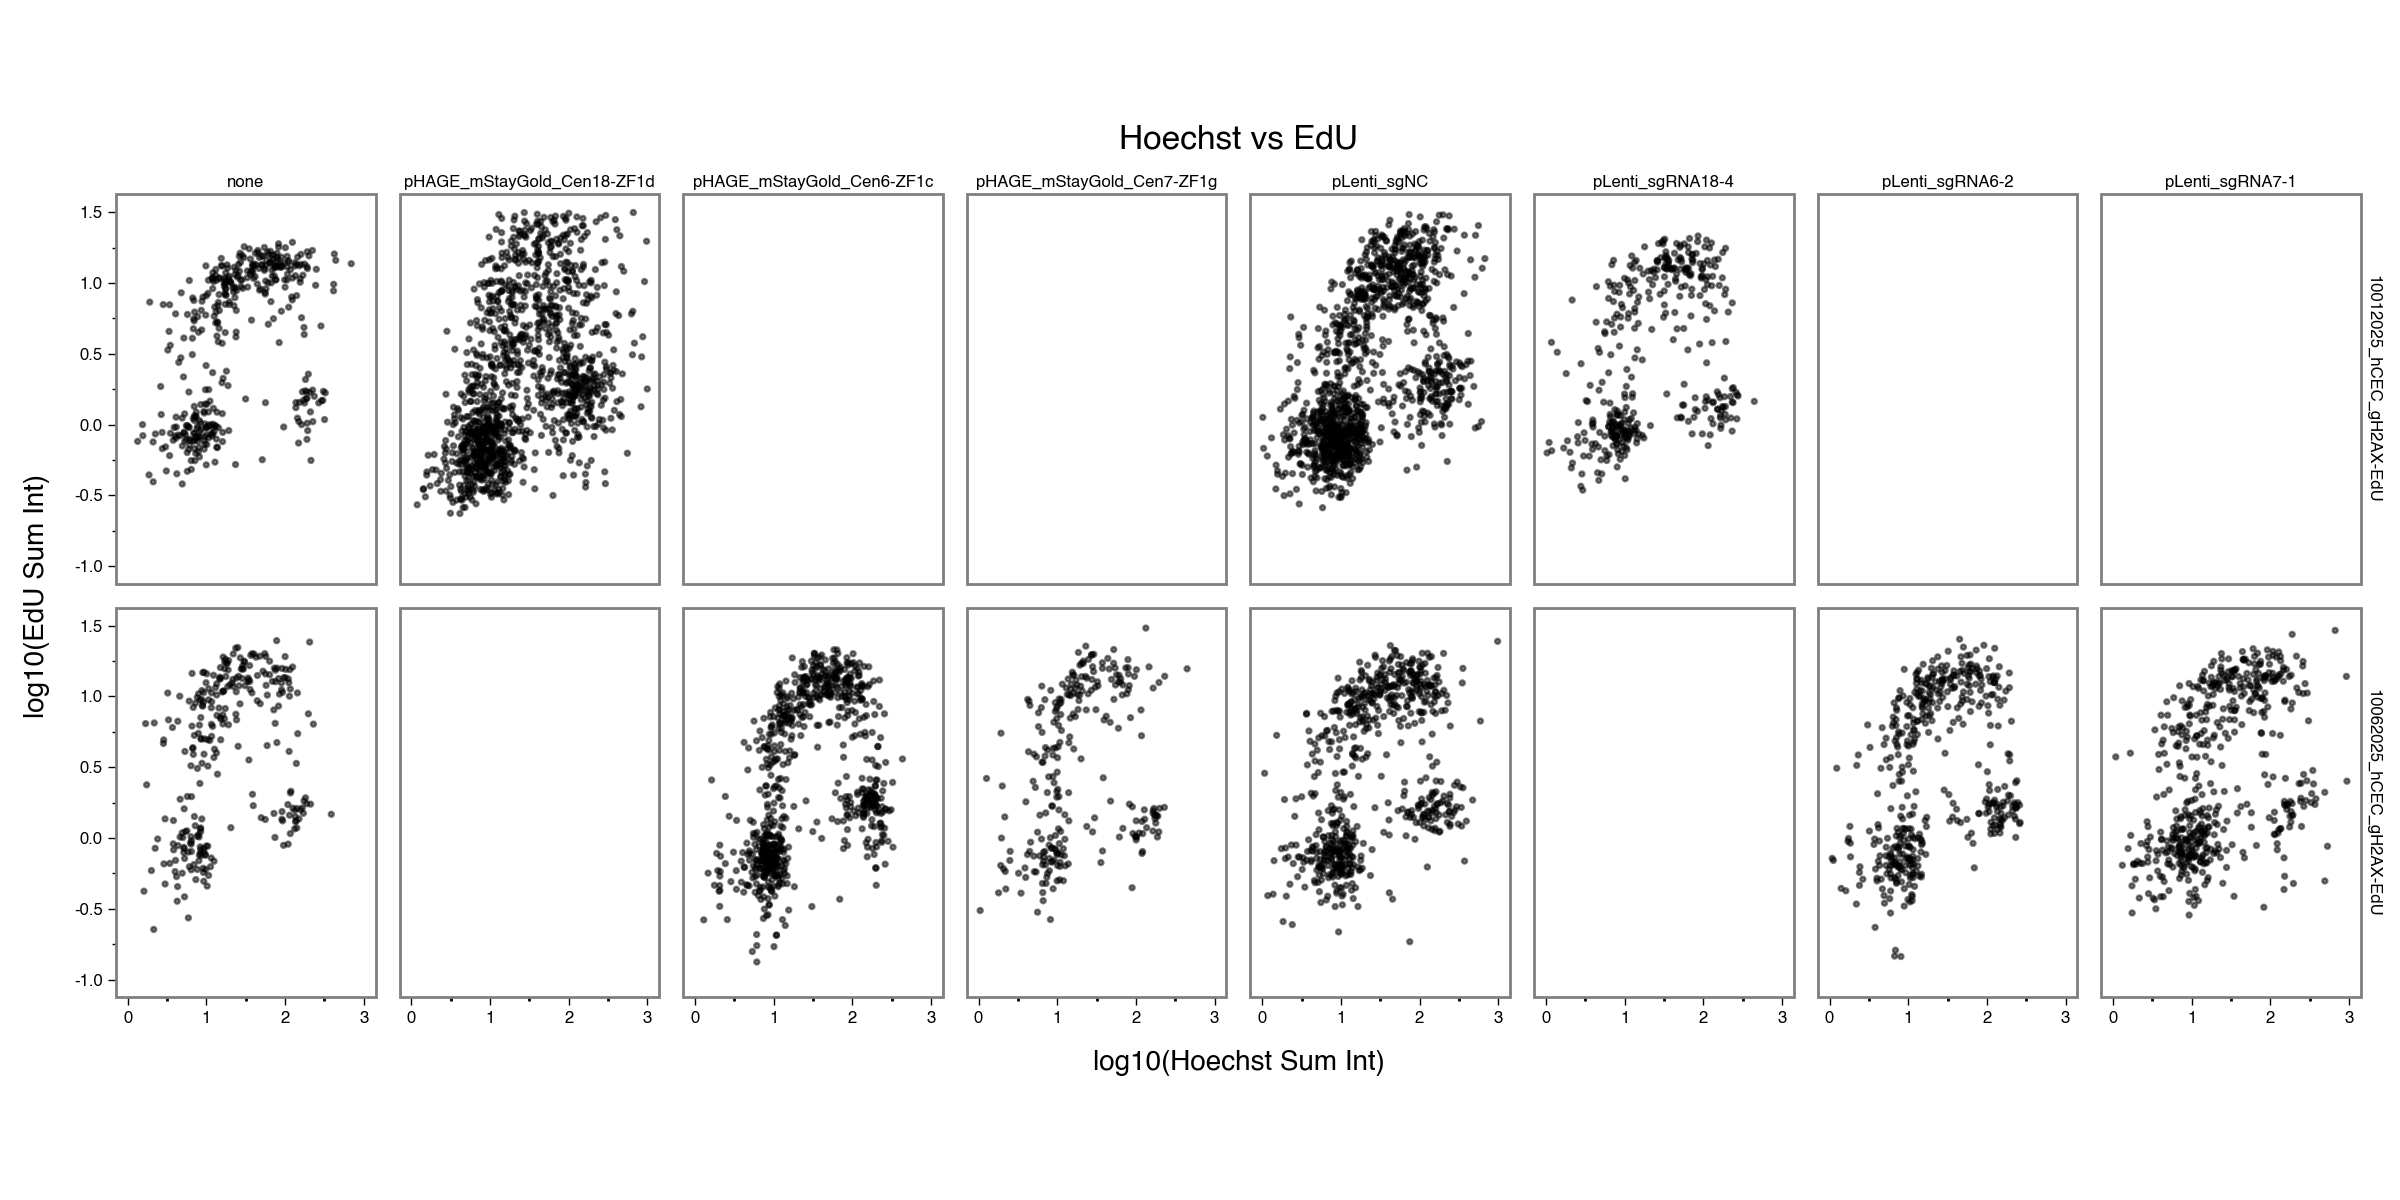

In [13]:
# Make the same plot as above but with re-scaled Hoechst values

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_scaled', 
                               y = 'ch4_scaled')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    #p9.scale_y_log10() +
    p9.labs(
        title = 'Hoechst vs EdU',
        x = 'log10(Hoechst Sum Int)',
        y = 'log10(EdU Sum Int)'
    ) + 
    p9.facet_grid('experiment ~ plasmid') +  # Create separate plots for each channel
    p9.lims(x = [0,3], y = [-1, 1.5]) +
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1.5,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill = 'white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

In [14]:
# Classify cells in 4 bins (G1, early S, late S, G2) based on Hoechst and EdU values

# Convenience aliases
H = wide_df["ch1_scaled"]  # Hoechst (scaled: G1≈1, G2≈2)
E = wide_df["ch4_scaled"]  # EdU (scaled: non-S≈0, S≈1)

# Define thresholding logic
conds = [
    (H < 1.5) & (E <= 0.25),     # G1
    (H < 1.5) & (E >  0.25),     # early S
    (H >= 1.5) & (E >  0.5),     # late S
    (H >= 1.5) & (E <= 0.5),     # G2
]
bins = [1, 2, 3, 4]

# Create 'bin' as nullable integer to allow NAs if anything falls outside logic
wide_df["bin"] = pd.Series(np.select(conds, bins, default=np.nan), index=wide_df.index).astype("Int64")

# Map to phase names
phase_map = {1: "G1", 2: "early S", 3: "late S", 4: "G2"}
wide_df["cc_phase"] = wide_df["bin"].map(phase_map)

# (Optional) make cc_phase an ordered categorical for nicer plotting/grouping
wide_df["cc_phase"] = pd.Categorical(
    wide_df["cc_phase"],
    categories=["G1", "early S", "late S", "G2"],
    ordered=True
)

# (Optional) quick sanity check
print(wide_df["bin"].value_counts(dropna = False).sort_index())
print(wide_df["cc_phase"].value_counts(dropna = False))

bin
1    2276
2    1515
3    1494
4     947
Name: count, dtype: Int64
cc_phase
G1         2276
early S    1515
late S     1494
G2          947
Name: count, dtype: int64


/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 121 rows containing missing values.


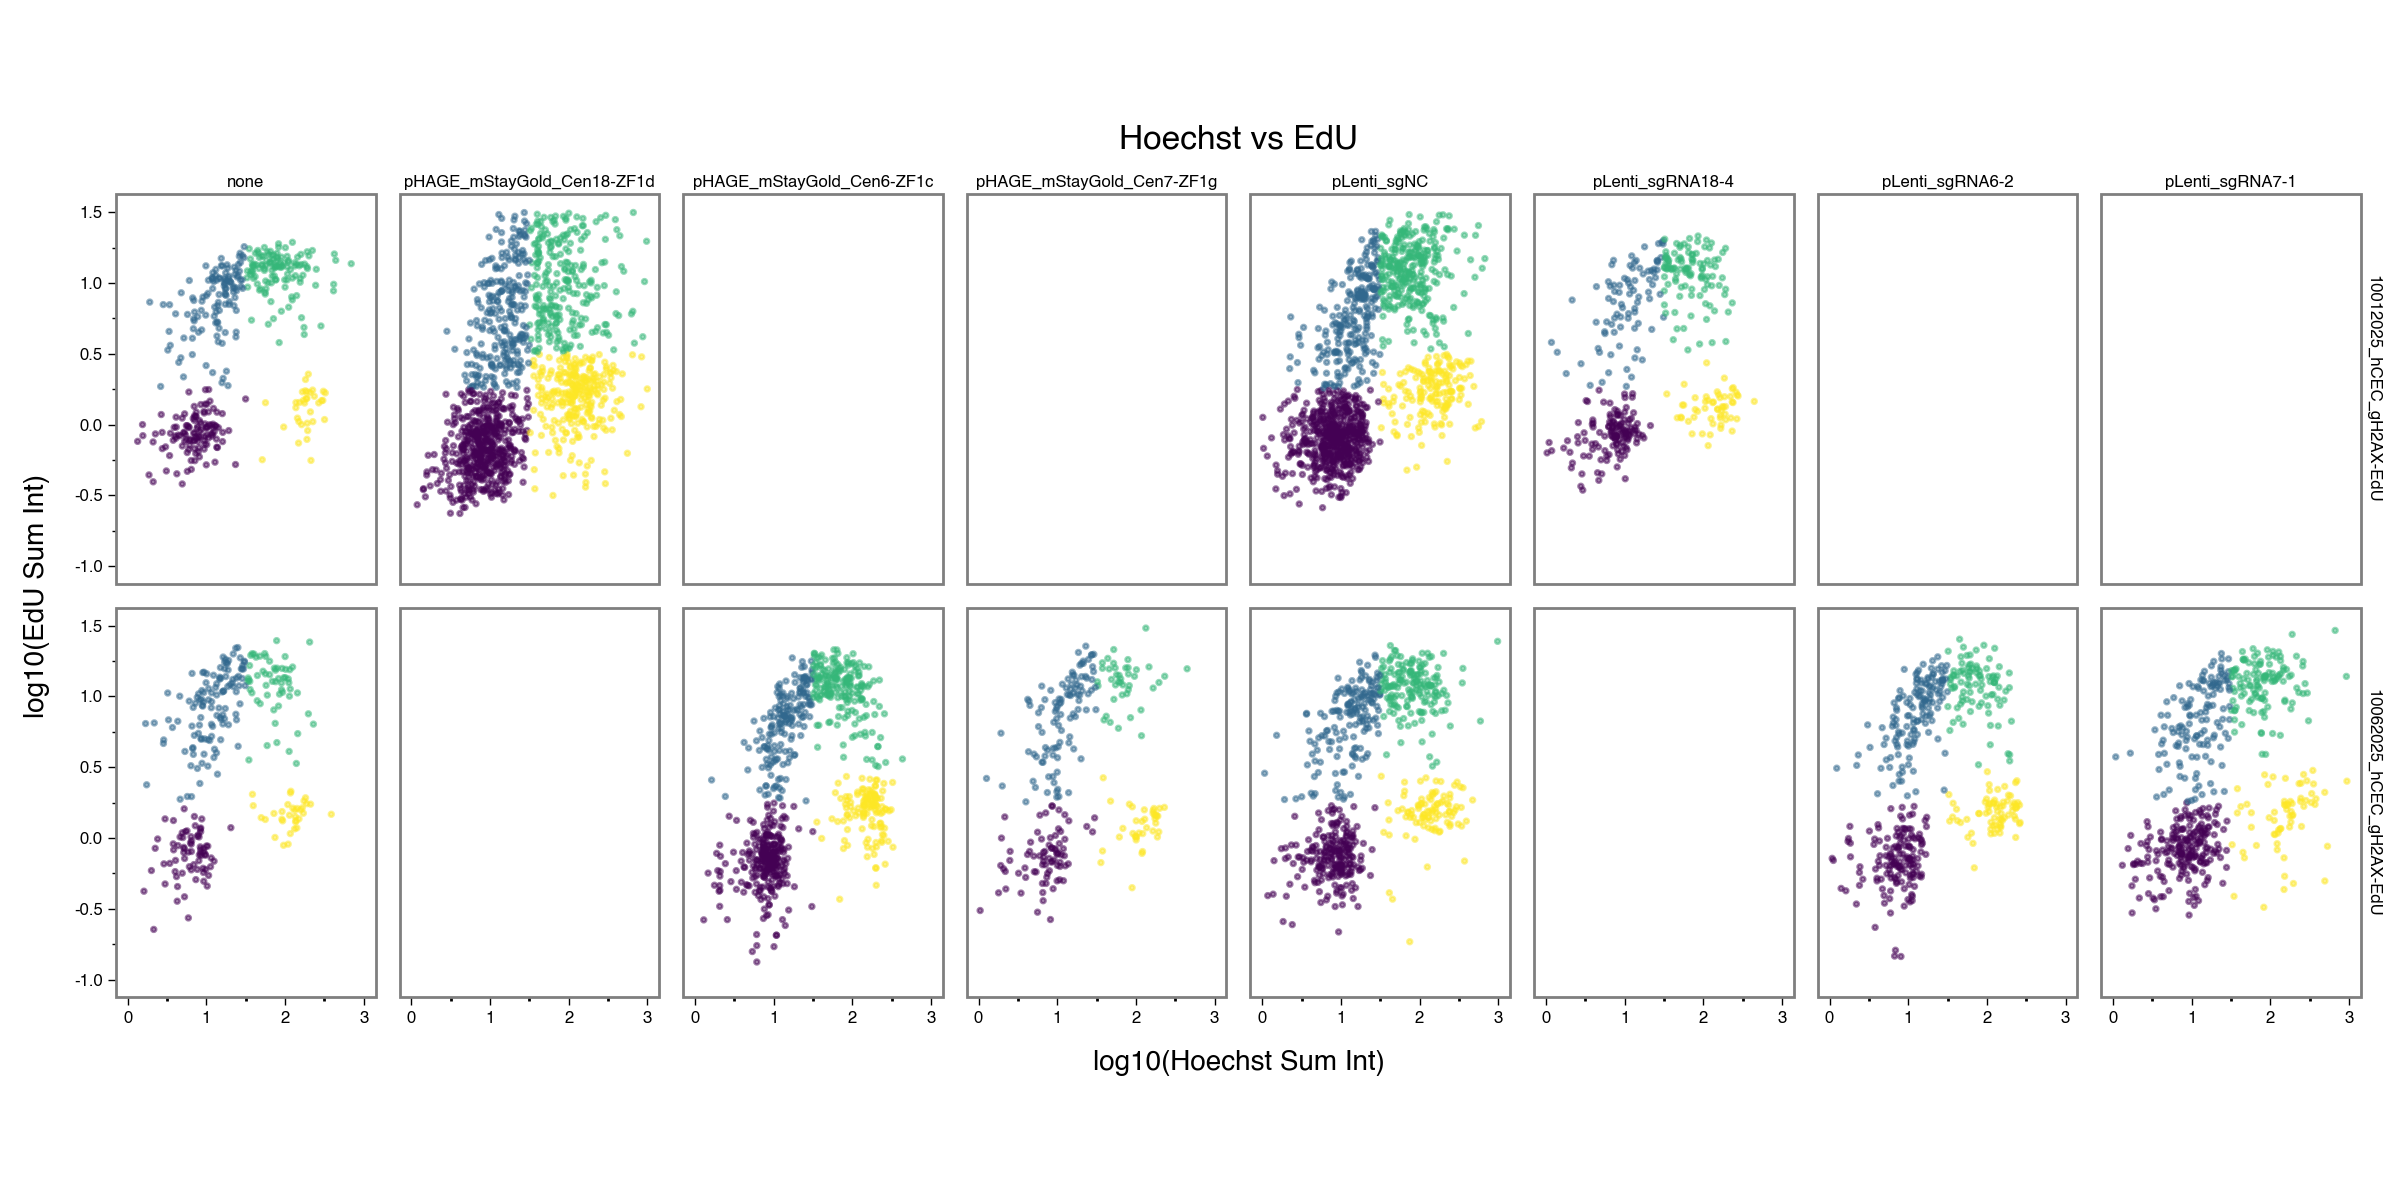

In [15]:
# Make the same plot as above but with color-coding for cell cycle phases

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_scaled', 
                               y = 'ch4_scaled', 
                               color = 'bin')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    #p9.scale_y_log10() +
    p9.labs(
        title = 'Hoechst vs EdU',
        x = 'log10(Hoechst Sum Int)',
        y = 'log10(EdU Sum Int)'
    ) + 
    p9.facet_grid('experiment ~ plasmid') +  # Create separate plots for each channel
    p9.lims(x = [0,3], y = [-1, 1.5]) +
    p9.scale_color_continuous() + 
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1.5,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill = 'white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

In [16]:
# Inspect the data frame with bins
print(wide_df.head())

                experiment  image_index  \
0  10012025_hCEC_gH2AX-EdU            0   
1  10012025_hCEC_gH2AX-EdU            0   
2  10012025_hCEC_gH2AX-EdU            0   
3  10012025_hCEC_gH2AX-EdU            0   
4  10012025_hCEC_gH2AX-EdU            0   

                                           base_name           plasmid  \
0  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
1  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
2  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
3  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   
4  10012025_hCEC_IF_sg18-4_dCas9-mStayGold_1_MMSt...  pLenti_sgRNA18-4   

          genotype   cell_line timepoint  ROI  ch1_sum_int  ch2_sum_int  \
0  dCas9:mStayGold  hCEC (D29)        t2    3   40722621.0    3800248.0   
1  dCas9:mStayGold  hCEC (D29)        t2    5   22000254.0    3362243.0   
2  dCas9:mStayGold  hCEC (D29)        t2    6   28706829.0    1853845.0

In [49]:
# Optional: extract only the cell cycle classification information
cols = [
    'experiment', 'base_name', 'plasmid', 
    'genotype', 'cell_line', 'timepoint', 
    'ROI', 'bin', 'cc_phase'
]
cc_class = wide_df.loc[:, cols].copy()

In [17]:
# Or skip the extraction above and just export the entire data frame
cc_class = wide_df.copy()

In [18]:
# FILE SAVING

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the Data Frame for the current experiment.
    # (Assumes your data frame includes an "experiment" column.)
    cc_class_exp = cc_class[cc_class['experiment'] == experiment]
    
    # Define the default file path for the CSV file
    cc_class_file = os.path.join(experiment_folder, "cc_class.csv")
    
    # If the cc_class file already exists, add the date suffix to create a new filename.
    if os.path.exists(cc_class_file):
        cc_class_file = os.path.join(experiment_folder, f"cc_class_{date_suffix}.csv")
    
    # Save the data frame to its CSV file
    cc_class_exp.to_csv(cc_class_file, index=False)